# Heart disease prediction with 5 ML models

This notebook loads the cleaned combined dataset from `combined_analysis.ipynb`, trains 5 different models, compares their performance, tunes a Random Forest, and evaluates the best model.

It expects `combined_cleaned.csv` to be present in this same folder.

In [ ]:
# STEP 1: Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

%matplotlib inline

print('Libraries imported successfully')

Libraries imported successfully


In [2]:
# STEP 2: Load Combined Dataset

data = pd.read_csv('combined_cleaned.csv')
print('Data shape:', data.shape)
data.head()

Data shape: (194805, 14)


,age,glucose,bloodpressure_x,bmi,outcome,chol,bloodpressure_y,sex,heart_disease,gender,smoke,amt_weekends,amt_weekdays,bmi_category
0,50,148,72,33.6,1,244,120,0,1,Female,No,NaN,NaN,Obese
1,50,148,72,33.6,1,244,120,0,1,Male,Yes,15.0,15.0,Obese
2,50,148,72,33.6,1,244,120,0,1,Female,No,NaN,NaN,Obese
3,50,148,72,33.6,1,244,120,0,1,Female,No,NaN,NaN,Obese
4,50,148,72,33.6,1,244,120,0,1,Male,No,NaN,NaN,Obese


In [3]:
# STEP 3: Define Target and Features

X = data.drop('heart_disease', axis=1)
y = data['heart_disease']

print('Features shape:', X.shape)
print('Target distribution:\n', y.value_counts())

Features shape: (194805, 13)
Target distribution:
 heart_disease
1    122490
0     72315
Name: count, dtype: int64


In [4]:
# STEP 4: Encode Categorical Variables

X = pd.get_dummies(X, drop_first=True)
print('Encoded features shape:', X.shape)

Encoded features shape: (194805, 15)


In [5]:
# STEP 5: Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (155844, 15)
Test shape: (38961, 15)


In [6]:
# STEP 6: Imputation + Feature Scaling

# Since some features may still contain NaN, impute first (all features are numeric after get_dummies)
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print('Imputation and feature scaling completed')

Imputation and feature scaling completed


In [7]:
# STEP 7: Train 5 Models

models = {
    'Logistic Regression': LogisticRegression(max_iter=300),
    'Decision Tree': DecisionTreeClassifier(max_depth=4, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=5, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=15),  # reduced variance vs k=5
    'Naive Bayes': GaussianNB()
}

results = {}

for name, model in models.items():
    if name == 'KNN':
        # For KNN, use 5-fold CV accuracy (with imputation + scaling)
        knn_pipeline = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
            ('knn', KNeighborsClassifier(n_neighbors=15))
        ])
        cv_scores = cross_val_score(knn_pipeline, X, y, cv=5)
        acc = cv_scores.mean()
        results[name] = acc
        print(f"{name} (5-fold CV) Accuracy: {acc:.4f}")
        # Also fit the KNN model on train data so we can use it later in STEP 8
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results[name] = acc
        print(f"{name} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 0.7106


Decision Tree Accuracy: 0.7522


Random Forest Accuracy: 0.7947


KNN (5-fold CV) Accuracy: 0.7293


Naive Bayes Accuracy: 0.7032


In [8]:
# STEP 8: Evaluation Metrics (Classification Reports)

for name, model in models.items():
    y_pred = model.predict(X_test)
    print('\n', name)
    print(classification_report(y_test, y_pred))


 Logistic Regression
              precision    recall  f1-score   support

           0       0.65      0.48      0.55     14463
           1       0.73      0.85      0.79     24498

    accuracy                           0.71     38961
   macro avg       0.69      0.66      0.67     38961
weighted avg       0.70      0.71      0.70     38961


 Decision Tree
              precision    recall  f1-score   support

           0       0.78      0.46      0.58     14463
           1       0.74      0.93      0.82     24498

    accuracy                           0.75     38961
   macro avg       0.76      0.69      0.70     38961
weighted avg       0.76      0.75      0.73     38961


 Random Forest
              precision    recall  f1-score   support

           0       0.84      0.55      0.67     14463
           1       0.78      0.94      0.85     24498

    accuracy                           0.79     38961
   macro avg       0.81      0.75      0.76     38961
weighted avg       0


 KNN
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     14463
           1       0.97      0.97      0.97     24498

    accuracy                           0.96     38961
   macro avg       0.96      0.96      0.96     38961
weighted avg       0.96      0.96      0.96     38961


 Naive Bayes
              precision    recall  f1-score   support

           0       0.61      0.54      0.58     14463
           1       0.75      0.80      0.77     24498

    accuracy                           0.70     38961
   macro avg       0.68      0.67      0.67     38961
weighted avg       0.70      0.70      0.70     38961



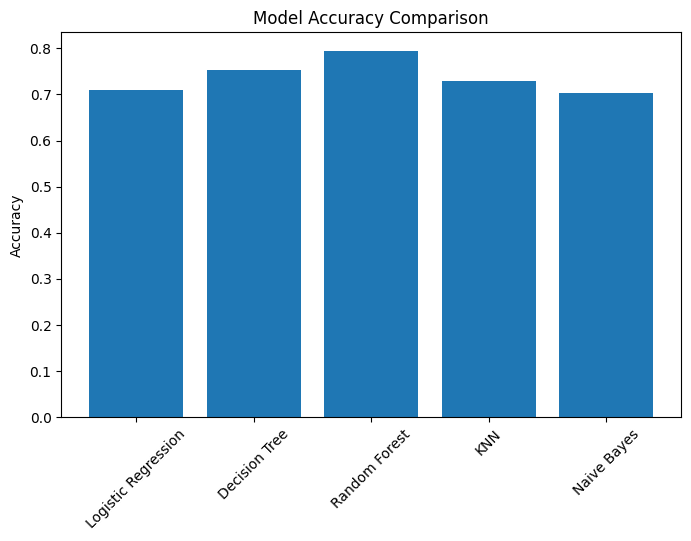

In [9]:
# STEP 9: Accuracy Comparison Plot

plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values())
plt.xticks(rotation=45)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

In [10]:
# STEP 10: Choose Best Model

best_model_name = max(results, key=results.get)
print('Best Model:', best_model_name)

Best Model: Random Forest


In [ ]:
# STEP 11: Hyperparameter Tuning (Random Forest - Aggressive Search)

# Baseline Random Forest (from STEP 7 results)
baseline_rf_acc = results.get('Random Forest', None)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 6, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

grid = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
y_pred_tuned = best_model.predict(X_test)

tuned_acc = accuracy_score(y_test, y_pred_tuned)

print("\n===== Random Forest Hyperparameter Tuning Results =====")
print("Best Parameters:", grid.best_params_)
print(f"Best CV Accuracy: {grid.best_score_:.4f}")
if baseline_rf_acc is not None:
    print(f"Test Accuracy Before Tuning: {baseline_rf_acc:.4f}")
else:
    print("Test Accuracy Before Tuning: (baseline not found in results dict)")
print(f"Test Accuracy After Tuning: {tuned_acc:.4f}")
if baseline_rf_acc is not None:
    improvement = (tuned_acc - baseline_rf_acc) / baseline_rf_acc * 100
    print(f"Percentage Improvement: {improvement:.2f}%")
print("======================================================\n")

Best Parameters: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 30}


In [12]:
# STEP 12: Evaluate Tuned Model

best_model = grid.best_estimator_

y_pred_tuned = best_model.predict(X_test)

print('Tuned Accuracy:', accuracy_score(y_test, y_pred_tuned))
print(classification_report(y_test, y_pred_tuned))

Tuned Accuracy: 0.7999281332614666
              precision    recall  f1-score   support

           0       0.84      0.57      0.68     14463
           1       0.79      0.93      0.85     24498

    accuracy                           0.80     38961
   macro avg       0.81      0.75      0.77     38961
weighted avg       0.81      0.80      0.79     38961



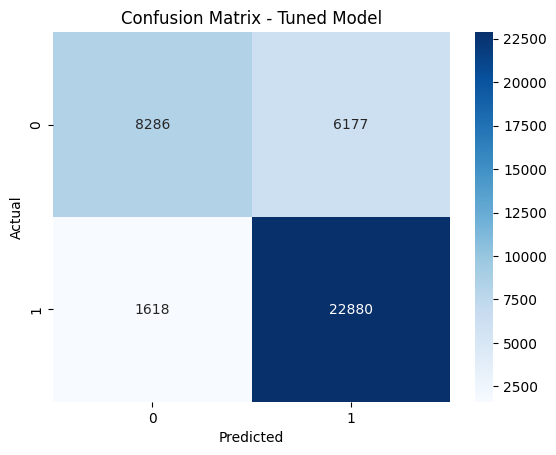

In [13]:
# STEP 13: Confusion Matrix

cm = confusion_matrix(y_test, y_pred_tuned)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Tuned Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

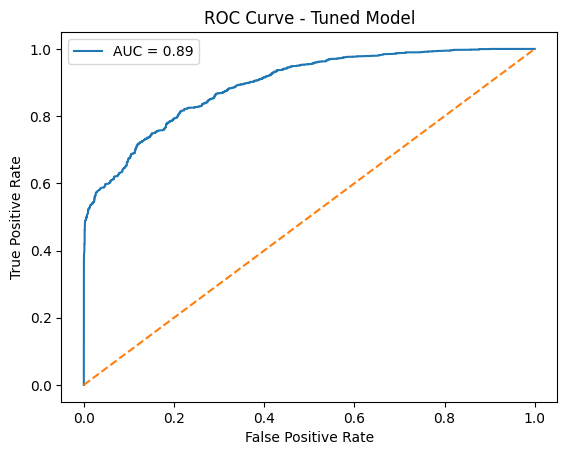

In [14]:
# STEP 14: ROC Curve

y_prob = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], '--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Model')
plt.legend()
plt.show()